<a href="https://colab.research.google.com/github/farhanwew/indoor-instace-segmentation/blob/main/Detectron/Detectron_2_Instance_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Roboflow and Detectron2 Pip Packages, Import Deps

In [1]:
!python -m pip install roboflow
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 126.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-271tqt57
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-271tqt57
  Resolved http

In [2]:
import logging
import torch
from collections import OrderedDict
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.engine import DefaultTrainer
from detectron2.utils.visualizer import ColorMode
from detectron2.solver import build_lr_scheduler, build_optimizer
from detectron2.checkpoint import DetectionCheckpointer, PeriodicCheckpointer
from detectron2.utils.events import EventStorage
from detectron2.modeling import build_model
import detectron2.utils.comm as comm
from detectron2.engine import default_argument_parser, default_setup, default_writers, launch
from detectron2.data import (
    MetadataCatalog,
    build_detection_test_loader,
    build_detection_train_loader,
)
from detectron2.evaluation import (
    CityscapesInstanceEvaluator,
    CityscapesSemSegEvaluator,
    COCOEvaluator,
    COCOPanopticEvaluator,
    DatasetEvaluators,
    LVISEvaluator,
    PascalVOCDetectionEvaluator,
    SemSegEvaluator,
    inference_on_dataset,
    print_csv_format,
)

from roboflow import Roboflow

from matplotlib import pyplot as plt
from PIL import Image

# Download dataset via Roboflow pip package and show a sample annotation

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ZACzFJOvzbToDyklrMEb")
project = rf.workspace("panopticindoor").project("panoptic-indoor-segmentation")
version = project.version(5)
dataset = version.download("coco-segmentation")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to panoptic-indoor-segmentation-5 in coco-segmentation:: 100%|██████████| 930/930 [00:00<00:00, 5453.76it/s]


In [ ]:
register_coco_instances(
    "my_train", {}, "/content/panoptic-indoor-segmentation-5/train/_annotations.coco.json", "/content/panoptic-indoor-segmentation-5/train/"
)
register_coco_instances(
    "my_valid", {}, "/content/panoptic-indoor-segmentation-5/valid/_annotations.coco.json", "/content/panoptic-indoor-segmentation-5/valid/"
)
register_coco_instances(
    "my_test", {}, "/content/panoptic-indoor-segmentation-5/test/_annotations.coco.json", "/content/panoptic-indoor-segmentation-5/test/"
)

In [ ]:
dataset_train = DatasetCatalog.get("my_train")
fig, ax = plt.subplots()
dataset_dict = random.choice(dataset_train)
im = Image.open(dataset_dict['file_name'])
ax.imshow(im)
for ann in dataset_dict['annotations']:
    for poly in ann['segmentation']:
        x = poly[0::2]
        y = poly[1::2]
        ax.plot(x,y, linewidth=2, color='red')

# Configure Detectron2 for fine tuning from COCO, Define training loop helper functions (from detectron2 repo), Run custom training loop

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("my_train",)#Train dataset registered in a previous cell
cfg.DATASETS.TEST = ("my_test",)#Test dataset registered in a previous cell
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 10000 #We found that with a patience of 500, training will early stop before 10,000 iterations
cfg.SOLVER.STEPS = []
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 74 # 26 letters plus one super class
cfg.TEST.EVAL_PERIOD = 0 # Increase this number if you want to monitor validation performance during training

PATIENCE = 100000 #Early stopping will occur after N iterations of no imporovement in total_loss
cfg.OUTPUT_DIR = "percobaan 2"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

In [26]:
from PIL import Image
import os
from pathlib import Path

# Just resize all images to match what Detectron2 expects
train_dir = '/content/panoptic-indoor-segmentation-5/train'

# Get all image files
image_files = [f for f in os.listdir(train_dir)
               if f.endswith(('.jpg', '.jpeg', '.png'))]

print(f"Found {len(image_files)} images")

for img_file in image_files:
    img_path = os.path.join(train_dir, img_file)

    try:
        with Image.open(img_path) as img:
            width, height = img.size

            # If dimensions are swapped (480x640 instead of 640x480)
            if width == 480 and height == 640:
                # Rotate the image
                img_rotated = img.rotate(90, expand=True)
                img_rotated.save(img_path)
                print(f"Rotated {img_file}: {width}x{height} -> {img_rotated.size}")
            else:
                print(f"Skipped {img_file}: {width}x{height}")
    except Exception as e:
        print(f"Error with {img_file}: {e}")

Found 397 images
Skipped 182169095_jpg.rf.a66825bd49fd7bb91aef272d1dde436e.jpg: 640x480
Skipped 182169270_jpg.rf.b7f0ef389d7f45fe2e12ca3947e03485.jpg: 640x480
Skipped 182169206_jpg.rf.0461750b619b55de91fb73f69ecfbc68.jpg: 640x480
Skipped 182169036_jpg.rf.7c95af8154c20503059faeffb7f6af78.jpg: 640x480
Skipped 182169068_jpg.rf.55405bf210aa32023553fe750bdb7a81.jpg: 640x480
Skipped 182169325_jpg.rf.993594c0e2bd6a6649fbc6e01a37f15d.jpg: 640x480
Skipped 182169211_jpg.rf.ae33c59997f799fc90470108216061e5.jpg: 640x480
Skipped 182169003_jpg.rf.042d94fddd2b6040b188c8412d0c95f8.jpg: 640x480
Skipped 182169250_jpg.rf.9ed9fdca93f39bceba92ddfc3d67ef92.jpg: 640x480
Skipped 182169154_jpg.rf.30b360c998abfea7808720cc22b429e8.jpg: 640x480
Skipped 182169193_jpg.rf.410026092017120fa20a93d1db7c5428.jpg: 640x640
Skipped 0685_jpg.rf.0797535456ee21a2d010895a07e7e84f.jpg: 640x640
Skipped 182169090_jpg.rf.0081914eea29aab55bc06b9585ed077b.jpg: 640x480
Skipped 182169410_jpg.rf.1541792206b1e7e07faa37a79f82cea0.jpg: 64

In [27]:
def get_evaluator(cfg, dataset_name, output_folder=None):
    """
    Create evaluator(s) for a given dataset.
    This uses the special metadata "evaluator_type" associated with each builtin dataset.
    For your own dataset, you can simply create an evaluator manually in your
    script and do not have to worry about the hacky if-else logic here.
    """
    if output_folder is None:
        output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
    evaluator_list = []
    evaluator_type = MetadataCatalog.get(dataset_name).evaluator_type
    if evaluator_type in ["sem_seg", "coco_panoptic_seg"]:
        evaluator_list.append(
            SemSegEvaluator(
                dataset_name,
                distributed=True,
                output_dir=output_folder,
            )
        )
    if evaluator_type in ["coco", "coco_panoptic_seg"]:
        evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
    if evaluator_type == "coco_panoptic_seg":
        evaluator_list.append(COCOPanopticEvaluator(dataset_name, output_folder))
    if evaluator_type == "cityscapes_instance":
        return CityscapesInstanceEvaluator(dataset_name)
    if evaluator_type == "cityscapes_sem_seg":
        return CityscapesSemSegEvaluator(dataset_name)
    if evaluator_type == "pascal_voc":
        return PascalVOCDetectionEvaluator(dataset_name)
    if evaluator_type == "lvis":
        return LVISEvaluator(dataset_name, cfg, True, output_folder)
    if len(evaluator_list) == 0:
        raise NotImplementedError(
            "no Evaluator for the dataset {} with the type {}".format(dataset_name, evaluator_type)
        )
    if len(evaluator_list) == 1:
        return evaluator_list[0]
    return DatasetEvaluators(evaluator_list)

def do_test(cfg, model):
    results = OrderedDict()
    for dataset_name in cfg.DATASETS.TEST:
        data_loader = build_detection_test_loader(cfg, dataset_name)
        evaluator = get_evaluator(
            cfg, dataset_name, os.path.join(cfg.OUTPUT_DIR, "inference", dataset_name)
        )
        results_i = inference_on_dataset(model, data_loader, evaluator)
        results[dataset_name] = results_i
        if comm.is_main_process():
            logger.info("Evaluation results for {} in csv format:".format(dataset_name))
            print_csv_format(results_i)
    if len(results) == 1:
        results = list(results.values())[0]
    return results


logger = logging.getLogger("detectron2")
resume=False
model = build_model(cfg)
optimizer = build_optimizer(cfg, model)
scheduler = build_lr_scheduler(cfg, optimizer)

BEST_LOSS = np.inf

checkpointer = DetectionCheckpointer(
    model, cfg.OUTPUT_DIR, optimizer=optimizer, scheduler=scheduler
)
start_iter = (
    checkpointer.resume_or_load(cfg.MODEL.WEIGHTS, resume=resume).get("iteration", -1) + 1
)
prev_iter = start_iter
max_iter = cfg.SOLVER.MAX_ITER

periodic_checkpointer = PeriodicCheckpointer(
    checkpointer, cfg.SOLVER.CHECKPOINT_PERIOD, max_iter=max_iter
)

writers = default_writers(cfg.OUTPUT_DIR, max_iter) if comm.is_main_process() else []

# compared to "train_net.py", we do not support accurate timing and
# precise BN here, because they are not trivial to implement in a small training loop
data_loader = build_detection_train_loader(cfg)
logger.info("Starting training from iteration {}".format(start_iter))
patience_counter = 0
with EventStorage(start_iter) as storage:
    for data, iteration in zip(data_loader, range(start_iter, max_iter)):
        storage.iter = iteration

        loss_dict = model(data)
        losses = sum(loss_dict.values())
        assert torch.isfinite(losses).all(), loss_dict

        loss_dict_reduced = {k: v.item() for k, v in comm.reduce_dict(loss_dict).items()}
        losses_reduced = sum(loss for loss in loss_dict_reduced.values())
        if comm.is_main_process():
            storage.put_scalars(total_loss=losses_reduced, **loss_dict_reduced)

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        storage.put_scalar("lr", optimizer.param_groups[0]["lr"], smoothing_hint=False)
        scheduler.step()

        if (
            cfg.TEST.EVAL_PERIOD > 0
            and (iteration + 1) % cfg.TEST.EVAL_PERIOD == 0
            and iteration != max_iter - 1
        ):
            do_test(cfg, model)
            # Compared to "train_net.py", the test results are not dumped to EventStorage
            comm.synchronize()

        if iteration - start_iter > 5 and (
            (iteration + 1) % 20 == 0 or iteration == max_iter - 1
        ):
            for writer in writers:
                writer.write()
        periodic_checkpointer.step(iteration)

        if iteration > prev_iter:
            prev_iter = iteration
            if losses_reduced < BEST_LOSS:
                BEST_LOSS = losses_reduced
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter % 100 == 0:
                    print(f"Loss has not improved for {patience_counter} iterations")
                if patience_counter >= PATIENCE:
                    print(f"EARLY STOPPING")
                    break

do_test(cfg, model)

[11/13 11:18:15 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl ...


roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


WARNING [11/13 11:18:16 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[11/13 11:18:16 d2.data.datasets.coco]: Loaded 397 images in COCO format from /content/panoptic-indoor-segmentation-5/train/_annotations.coco.json
[11/13 11:18:16 d2.data.build]: Removed 0 images with no usable annotations. 397 images left.
[11/13 11:18:16 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in training: [ResizeShortestEdge(short_edge_length=(640, 672, 704, 736, 768, 800), max_size=1333, sample_style='choice'), RandomFlip()]
[11/13 11:18:16 d2.data.build]: Using training sampler TrainingSampler
[11/13 11:18:16 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[11/13 11:18:16 d2.data.common]: Serializing 397 elements to byte tensors and concatenating them all ...
[11/13 11:18:16 d2.data.common]: Serialized dataset takes 1.48 MiB
[11/13 11:18:16 d2.data.build]: Making batched d

OrderedDict([('bbox',
              {'AP': 9.793734065831702,
               'AP50': 17.092882045396056,
               'AP75': 10.433082903001715,
               'APs': 6.402169994351064,
               'APm': 8.69788417449458,
               'APl': 13.01860512053093,
               'AP-indoor-objects': nan,
               'AP-backpack': 8.8512546309576,
               'AP-bed': 10.948155267021372,
               'AP-blanket': 0.6786574854216654,
               'AP-book': 11.313199426297903,
               'AP-bottle': 24.547079413152105,
               'AP-bowl': 32.74233217090548,
               'AP-box': 0.19337016574585633,
               'AP-cabinet-merged': 3.9496989397125897,
               'AP-cardboard': 0.0,
               'AP-ceiling-merged': 24.6192029243532,
               'AP-cell phone': 15.567328018902801,
               'AP-chair': 31.906209748446713,
               'AP-clock': 38.01980198019802,
               'AP-couch': 15.730439994072482,
               'AP-counte

In [11]:
import cv2
img = cv2.imread("/content/panoptic-indoor-segmentation-5/train/182169107_jpg.rf.c9b1bbecf1474a5b36a6df197c30dfed.jpg")
print(img.shape)


(480, 640, 3)


In [13]:
cfg.OUTPUT_DIR

'./output'

# Test model and show example output

[11/13 13:44:52 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from percobaan 2/model_final.pth ...
WARNING [11/13 13:44:52 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[11/13 13:44:52 d2.data.datasets.coco]: Loaded 166 images in COCO format from /content/panoptic-indoor-segmentation-5/valid/_annotations.coco.json


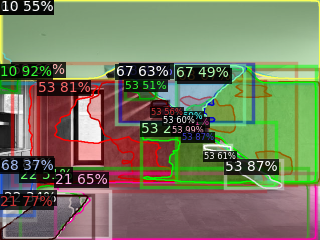

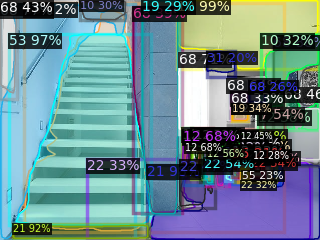

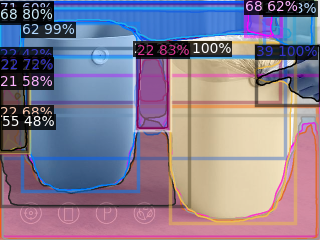

In [34]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.2   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

dataset_dicts = DatasetCatalog.get("my_valid")
for d in random.sample(dataset_dicts, 3):
    im = cv2.imread(d["file_name"])
    outputs = predictor(im)
    v = Visualizer(im[:, :, ::-1],
                   scale=0.5,
                   instance_mode=ColorMode.IMAGE_BW
    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    im = Image.fromarray(out.get_image()[:, :, ::-1])
    display(im) # Explicitly display each image

# Download trained model for future inference

In [33]:
from google.colab import files
files.download(os.path.join(cfg.OUTPUT_DIR, "model_final.pth"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
os.makedirs("/content/drive/MyDrive/indoor - seg/detectron", exist_ok=True)

In [37]:
!cp -r "/content/percobaan 2/" "/content/drive/MyDrive/indoor - seg/detectron"
!cp -r "/content/output/" "/content/drive/MyDrive/indoor - seg/detectron"